In [11]:
# Install kagglehub (for easy Kaggle dataset download)
!pip install -q kagglehub

import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import DenseNet121

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [12]:
# Download the dataset (public, no API key required)
print("Downloading dataset from Kaggle...")
dataset_path = kagglehub.dataset_download("ninadaithal/imagesoasis")
print(f"Dataset downloaded to: {dataset_path}")

# The dataset contains a "Data" folder with class subfolders
data_dir = os.path.join(dataset_path, "Data")

# If "Data" is not directly inside, search for it
if not os.path.exists(data_dir):
    for root, dirs, files in os.walk(dataset_path):
        if "Data" in dirs:
            data_dir = os.path.join(root, "Data")
            break

if not os.path.exists(data_dir):
    raise FileNotFoundError("Could not find 'Data' folder in the downloaded dataset.")

print(f"Data folder found at: {data_dir}")

# Class names (must match folder names inside Data)
class_names = [
    "Non Demented",
    "Very mild Dementia",
    "Mild Dementia",
    "Moderate Dementia"
]
num_classes = len(class_names)

100%|██████████| 1.23G/1.23G [01:00<00:00, 21.9MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/ninadaithal/imagesoasis/versions/1
Data folder found at: /root/.cache/kagglehub/datasets/ninadaithal/imagesoasis/versions/1/Data


In [13]:
data = {}
for label in os.listdir(data_dir):
    class_path = os.path.join(data_dir, label)
    if os.path.isdir(class_path):
        images = [os.path.join(class_path, img) for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        data[label] = images

for k, v in data.items():
    print(f"{k}: {len(v)} images")

Moderate Dementia: 488 images
Very mild Dementia: 13725 images
Non Demented: 67222 images
Mild Dementia: 5002 images


In [14]:
train_data = []
test_data = []

for label, images in data.items():
    train, test = train_test_split(
        images,
        test_size=0.1,
        random_state=42
    )
    train_data.append(pd.DataFrame({"path": train, "label": label}))
    test_data.append(pd.DataFrame({"path": test, "label": label}))

train_df = pd.concat(train_data)
test_df = pd.concat(test_data)

In [15]:
target_samples = 5000
balanced_data = []

for label in data.keys():
    subset = train_df[train_df["label"] == label]
    paths = subset["path"].tolist()
    if len(paths) >= target_samples:
        sampled = random.sample(paths, target_samples)
    else:
        sampled = random.choices(paths, k=target_samples)
    balanced_data.append(pd.DataFrame({"path": sampled, "label": label}))

balanced_df = pd.concat(balanced_data)
print(balanced_df["label"].value_counts())

label
Moderate Dementia     5000
Very mild Dementia    5000
Non Demented          5000
Mild Dementia         5000
Name: count, dtype: int64


In [16]:
train_df, val_df = train_test_split(
    balanced_df,
    test_size=0.2,
    stratify=balanced_df["label"],
    random_state=42
)

In [17]:
IMG_SIZE = 128
BATCH = 32

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode="categorical"
)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    x_col="path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode="categorical"
)

test_gen = val_datagen.flow_from_dataframe(
    test_df,
    x_col="path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=False
)

Found 16000 validated image filenames belonging to 4 classes.
Found 4000 validated image filenames belonging to 4 classes.
Found 8646 validated image filenames belonging to 4 classes.


In [18]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

model = Sequential()
model.add(Conv2D(32, (2, 2), padding="same", input_shape=(128, 128, 3)))
model.add(Conv2D(32, (2, 2), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (2, 2), activation="relu", padding="same"))
model.add(Conv2D(64, (2, 2), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(512, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(4, activation="softmax"))

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=[early_stop]
)

Epoch 1/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 61ms/step - accuracy: 0.5547 - loss: 2.4770 - val_accuracy: 0.2752 - val_loss: 27.0201
Epoch 2/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 29s 57ms/step - accuracy: 0.7117 - loss: 0.6038 - val_accuracy: 0.8225 - val_loss: 0.3817
Epoch 3/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.7878 - loss: 0.4720 - val_accuracy: 0.8307 - val_loss: 0.3591
Epoch 4/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.8263 - loss: 0.3921 - val_accuracy: 0.9250 - val_loss: 0.1947
Epoch 5/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - accuracy: 0.8564 - loss: 0.3316 - val_accuracy: 0.9093 - val_loss: 0.2274
Epoch 6/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 57ms/step - accuracy: 0.8761 - loss: 0.2800 - val_accuracy: 0.9477 - val_loss: 0.1397
Epoch 7/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - accuracy: 0.8738 - loss: 0.3007 - val_accuracy: 0.9410 - val_loss: 0.1256
Epoch 8/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - accuracy: 0.8905 - loss: 0.2563 -

In [20]:
test_eval = model.evaluate(test_gen, verbose=2)
print("Custom CNN Test Loss:", test_eval[0])
print("Custom CNN Test Accuracy:", test_eval[1])

271/271 - 12s - 45ms/step - accuracy: 0.9557 - loss: 0.1198
Custom CNN Test Loss: 0.11977647244930267
Custom CNN Test Accuracy: 0.9557020664215088


In [21]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(4, activation="softmax")(x)

densenet_model = Model(inputs=base_model.input, outputs=output)

for layer in base_model.layers[:-40]:
    layer.trainable = False

densenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [22]:
history_dense = densenet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 84s 88ms/step - accuracy: 0.6735 - loss: 0.8061 - val_accuracy: 0.8788 - val_loss: 0.3406
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.8799 - loss: 0.3163 - val_accuracy: 0.9335 - val_loss: 0.1757
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.9381 - loss: 0.1693 - val_accuracy: 0.9510 - val_loss: 0.1348
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.9672 - loss: 0.0937 - val_accuracy: 0.9675 - val_loss: 0.0883


In [23]:
model.save('custom_cnn_model.h5')
print("Custom CNN model saved as custom_cnn_model.h5")

Custom CNN model saved as custom_cnn_model.h5


In [24]:
densenet_model.save('densenet_model.h5')
print("DenseNet model saved as densenet_model.h5")

DenseNet model saved as densenet_model.h5


271/271 ━━━━━━━━━━━━━━━━━━━━ 43s 99ms/step
                    precision    recall  f1-score   support

     Mild Dementia       0.56      0.89      0.68       501
 Moderate Dementia       0.57      1.00      0.73        49
      Non Demented       0.98      0.69      0.81      6723
Very mild Dementia       0.41      0.89      0.56      1373

          accuracy                           0.74      8646
         macro avg       0.63      0.87      0.70      8646
      weighted avg       0.86      0.74      0.76      8646



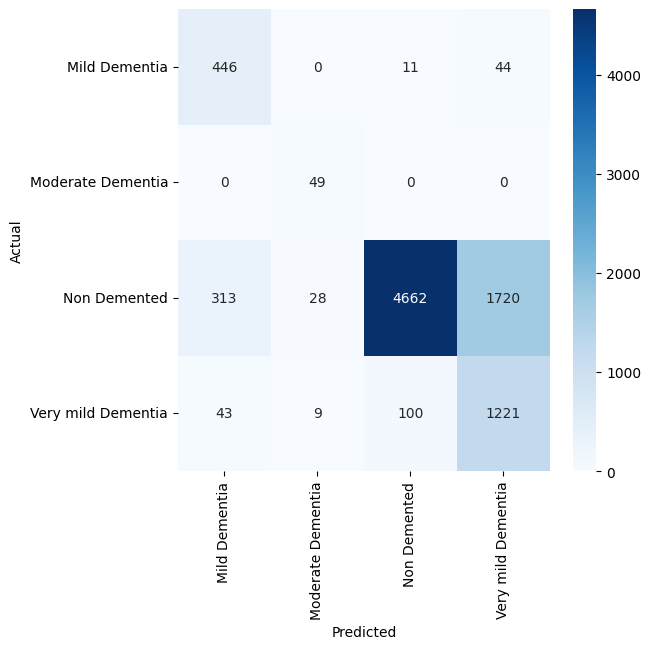

In [25]:
pred = densenet_model.predict(test_gen)
y_pred = np.argmax(pred, axis=1)
y_true = test_gen.classes

print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_gen.class_indices.keys())
))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=list(test_gen.class_indices.keys()),
    yticklabels=list(test_gen.class_indices.keys())
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


CUSTOM CNN TEST PERFORMANCE
271/271 - 14s - 52ms/step - accuracy: 0.9557 - loss: 0.1198
Test Loss: 0.1198
Test Accuracy: 0.9557

DENSENET TEST PERFORMANCE
271/271 - 25s - 91ms/step - accuracy: 0.7377 - loss: 0.5988
Test Loss: 0.5988
Test Accuracy: 0.7377


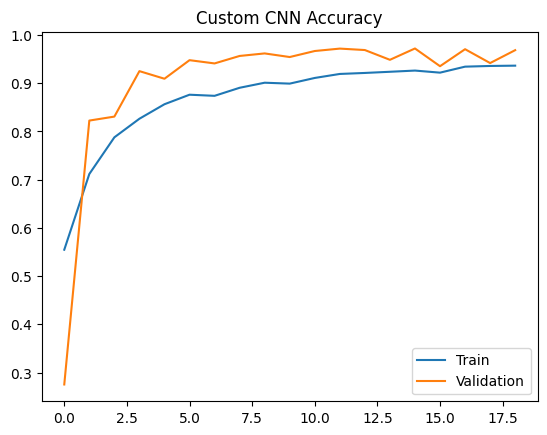

In [26]:
print("\n" + "="*30)
print("CUSTOM CNN TEST PERFORMANCE")
print("="*30)
cnn_test = model.evaluate(test_gen, verbose=2)
print(f"Test Loss: {cnn_test[0]:.4f}")
print(f"Test Accuracy: {cnn_test[1]:.4f}")

print("\n" + "="*30)
print("DENSENET TEST PERFORMANCE")
print("="*30)
dense_test = densenet_model.evaluate(test_gen, verbose=2)
print(f"Test Loss: {dense_test[0]:.4f}")
print(f"Test Accuracy: {dense_test[1]:.4f}")

# Custom CNN accuracy plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Custom CNN Accuracy")
plt.legend(["Train", "Validation"])
plt.show()